In [2]:
#installing dependencies
import os
import pandas as pd
import tensorflow as tf
import numpy as np

In [3]:
df = pd.read_csv('./da/train.csv')

In [4]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
df.tail()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0,0,0,0


In [6]:
df.iloc[7]['comment_text']

"Your vandalism to the Matt Shirvington article has been reverted.  Please don't do it again, or you will be banned."

In [7]:
df[df.columns[2:]].iloc[5]

toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
Name: 5, dtype: int64

In [8]:
#preprocessing
from tensorflow.keras.layers import TextVectorization

TextVectorization #take word and convert to a word

keras.src.layers.preprocessing.text_vectorization.TextVectorization

In [9]:
X = df['comment_text']
y = df[df.columns[2:]].values

In [10]:
MAX_FEATURES = 200000 # number of words in vocab

In [11]:
vectorizer = TextVectorization(max_tokens=MAX_FEATURES, output_sequence_length=1800, output_mode='int') #mapping words to  integers, training

In [12]:
type(X.values)
vectorizer.adapt(X.values)

In [13]:
vectorizer.get_vocabulary()

['',
 '[UNK]',
 np.str_('the'),
 np.str_('to'),
 np.str_('of'),
 np.str_('and'),
 np.str_('a'),
 np.str_('you'),
 np.str_('i'),
 np.str_('is'),
 np.str_('that'),
 np.str_('in'),
 np.str_('it'),
 np.str_('for'),
 np.str_('this'),
 np.str_('not'),
 np.str_('on'),
 np.str_('be'),
 np.str_('as'),
 np.str_('have'),
 np.str_('are'),
 np.str_('your'),
 np.str_('with'),
 np.str_('if'),
 np.str_('article'),
 np.str_('was'),
 np.str_('or'),
 np.str_('but'),
 np.str_('page'),
 np.str_('my'),
 np.str_('an'),
 np.str_('from'),
 np.str_('by'),
 np.str_('do'),
 np.str_('at'),
 np.str_('about'),
 np.str_('me'),
 np.str_('so'),
 np.str_('wikipedia'),
 np.str_('can'),
 np.str_('what'),
 np.str_('there'),
 np.str_('all'),
 np.str_('has'),
 np.str_('will'),
 np.str_('talk'),
 np.str_('please'),
 np.str_('would'),
 np.str_('its'),
 np.str_('no'),
 np.str_('one'),
 np.str_('just'),
 np.str_('like'),
 np.str_('they'),
 np.str_('he'),
 np.str_('dont'),
 np.str_('which'),
 np.str_('any'),
 np.str_('been'),
 np

In [14]:
vectorizer('Hello world, life is great')[:5]

<tf.Tensor: shape=(5,), dtype=int64, numpy=array([288, 263, 306,   9, 275])>

In [15]:
vectorizer.get_vocabulary()
vectorized_text = vectorizer(X.values) #tokenize every single word
len(X)
vectorized_text

<tf.Tensor: shape=(159571, 1800), dtype=int64, numpy=
array([[  645,    76,     2, ...,     0,     0,     0],
       [    1,    54,  2489, ...,     0,     0,     0],
       [  425,   441,    70, ...,     0,     0,     0],
       ...,
       [32445,  7392,   383, ...,     0,     0,     0],
       [    5,    12,   534, ...,     0,     0,     0],
       [    5,     8,   130, ...,     0,     0,     0]],
      shape=(159571, 1800))>

In [16]:
#map cache shuffle batch prefetch to build data pipeline
dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
dataset = dataset.cache()
dataset = dataset.shuffle(160000)
dataset = dataset.batch(16)
dataset = dataset.prefetch(8)

In [17]:
batch_X, batch_y = dataset.as_numpy_iterator().next()

In [18]:
batch_X.shape
batch_y.shape

(16, 6)

In [19]:
train = dataset.take(int(len(dataset)*.7))
val = dataset.skip(int(len(dataset)*.7)).take(int(len(dataset)*.2))
test = dataset.skip(int(len(dataset)*.9)).take(int(len(dataset)*.1))

In [20]:
len(test)

997

In [21]:
train_generator = train.as_numpy_iterator()

In [22]:
train_generator.next() # model forward pass, upgrade gradients
#36 min

(array([[    8,    19,   389, ...,     0,     0,     0],
        [  607,   389,   122, ...,     0,     0,     0],
        [  943,    48,    51, ...,     0,     0,     0],
        ...,
        [64902,    12,     9, ...,     0,     0,     0],
        [    7,  1923,   155, ...,     0,     0,     0],
        [ 4266,   424,  4266, ...,     0,     0,     0]], shape=(16, 1800)),
 array([[0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0]]))

In [23]:
# creating sequential model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Bidirectional, Dense, Embedding # layers

In [24]:
model = Sequential()
#create the embedding layer
model.add(Embedding(MAX_FEATURES+1, 32))
#pass info both ways, bidirectional LSTM layer
model.add(Bidirectional(LSTM(32, activation='tanh')))

#feature extractor fully connected layers
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
#final layer
model.add(Dense(6, activation='sigmoid'))


In [25]:
model.compile(loss='BinaryCrossentropy', optimizer='Adam')

In [26]:
model.summary()
#

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(train, epochs=5, validation_data=val)

Epoch 1/5
 389/6981 ━━━━━━━━━━━━━━━━━━━━ 14:44 134ms/step - loss: 0.2043

KeyboardInterrupt: 

<Figure size 800x500 with 0 Axes>

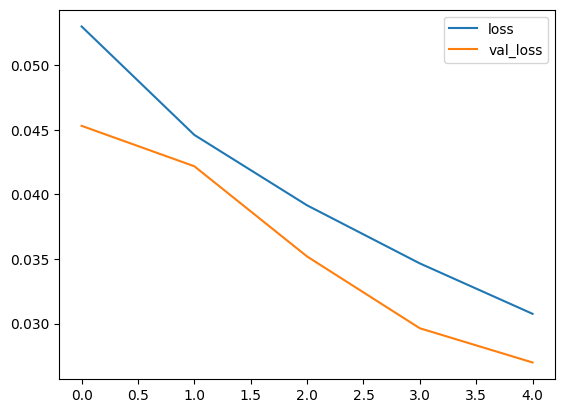

In [47]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))
pd.DataFrame(history.history).plot()
plt.show()

In [1]:
input_text = vectorizer("Dummy nodes") #vectorizing text
batch = test.as_numpy_iterator().next()
batch_X, batch_y = test.as_numpy_iterator().next()
model.predict(batch_X) #pass to model to predict

model.predict(np.expand_dims(input_text, 0))
res = model.predict(np.expand_dims(input_text, 0))


NameError: name 'vectorizer' is not defined

In [ ]:
#eval model
from tensorflow.keras.metrics import Precision, Recall, CategoricalAccuracy

pre = Precision()
re = Recall()
acc = CategoricalAccuracy()

In [ ]:
#go through single batch
for batch in test.as_numpy_iterator():
    #unpack the batch
    X_true, y_true = batch
    #make a prediction
    yhat = model.predict(X_true)
    #flaten predictions
    y_true = y_true.flatten()
    yhat=yhat.flatten()
    pre.update_state(y_true, yhat)
    re.update_state(y_true, yhat)
    acc.update_state(y_true, yhat)

In [28]:
print(f'Precision: {pre.result().numpy()},Recall:{re.result().numpy()},Accuracy:{acc.result().numpy()}')

NameError: name 'pre' is not defined

In [ ]:
#test and gradio
import gradio as gr
import tensorflow as tf
model.save('toxicity.h5')
#saving model
model = tf.keras.model.load_model('toxicity.h5')


In [ ]:
input_str = vectorizer('hey thats freaking awful, im gonna hurt and punch u in GTA V')
res = model.predict(np.expand_dims(input_str, 0))
res
df.columns[2:]

In [ ]:
def score_comment(comment):
    vectorized_comment = vectorizer([comment]) #pass comment to vectorizer from text to numbers
    results = model.predict(vectorized_comment)

    txt = ''
    for idx, col in enumerate(df.columns[2:-1]):
        txt += '{}: {}\n'.format(col, results[0][idx]>0.5)
    return txt

In [ ]:
import gradio as gr
interface = gr.Interface(fn=score_comment, inputs=gr.inputs.Textbox(lines=2, placeholder='Comment to score'), outputs='text') #crate gradio interface for launching

In [ ]:
interface.launch(share=True)